<a href="https://colab.research.google.com/github/Nik2416/Time-Series/blob/main/Time_Series_LOESS_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed


Amazon stock data:
Price         Close     High      Low     Open    Volume
Ticker         AMZN     AMZN     AMZN     AMZN      AMZN
Date                                                    
2015-01-02  15.4260  15.7375  15.3480  15.6290  55664000
2015-01-05  15.1095  15.4190  15.0425  15.3505  55484000
2015-01-06  14.7645  15.1500  14.6190  15.1120  70380000
2015-01-07  14.9210  15.0640  14.7665  14.8750  52806000
2015-01-08  15.0230  15.1570  14.8055  15.0160  61768000

Monthly data:
Date
2015-01-01    17.726500
2015-02-01    19.007999
2015-03-01    18.605000
2015-04-01    21.089001
2015-05-01    21.461500
Freq: MS, Name: AMZN, dtype: float64


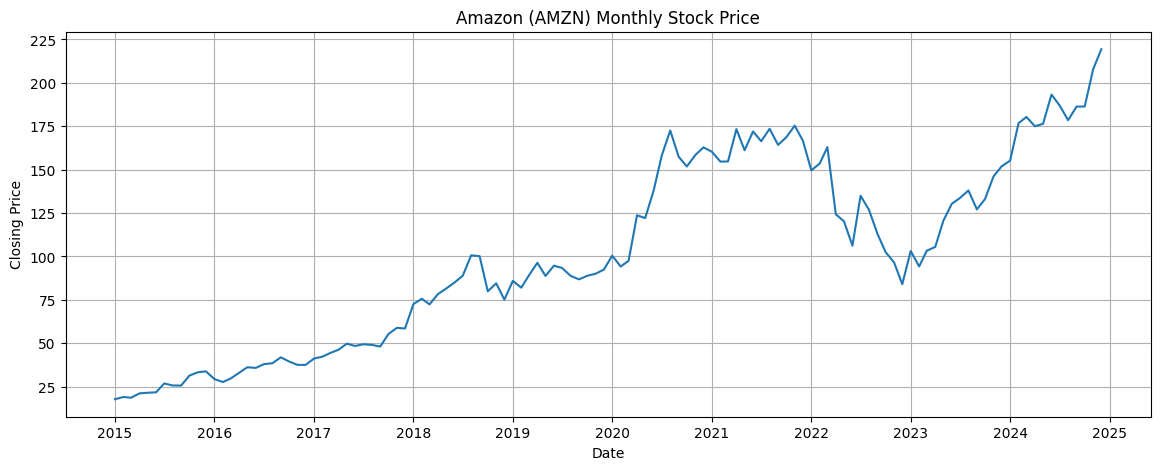

/tmp/ipykernel_1723/472048701.py:86: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_test = adfuller(monthly_data)
/tmp/ipykernel_1723/472048701.py:112: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_test_diff = adfuller(diff_data)



ADF TEST
--------------------------------
ADF Statistic: -0.33005125889208226
p-value: 0.9211390216113752
The data is NOT stationary.
Differencing is required.

ADF TEST AFTER DIFFERENCING
--------------------------------
ADF Statistic: -11.64268408510265
p-value: 2.1282396010247365e-21
The differenced data is stationary.


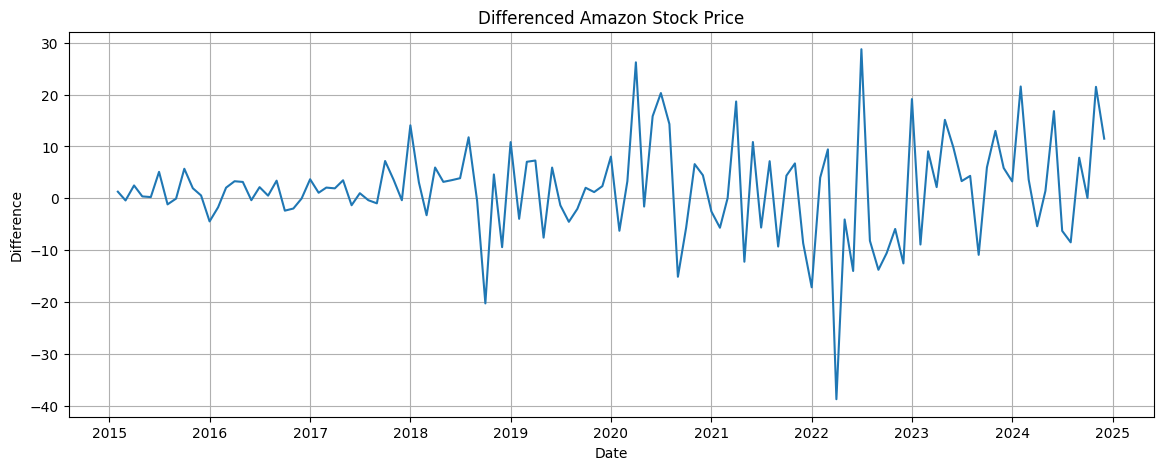


Training observations: 96
Testing observations: 24

ARIMA MODEL SUMMARY
--------------------------------
                               SARIMAX Results                                
Dep. Variable:                   AMZN   No. Observations:                   96
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -344.940
Date:                Thu, 08 Oct 2026   AIC                            695.879
Time:                        14:48:44   BIC                            703.541
Sample:                    01-01-2015   HQIC                           698.975
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7249      0.455     -1.593      0.111      -1.617       0.167
ma.L1          0.6504    

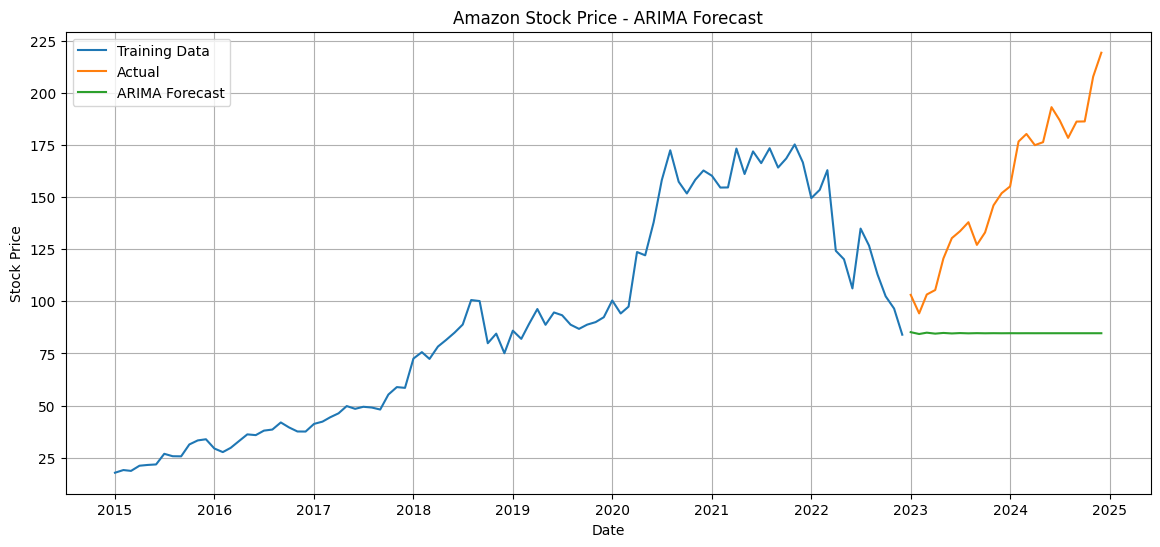


MODEL PERFORMANCE
--------------------------------
MAE : 69.84571026757243
RMSE: 78.10831237122277


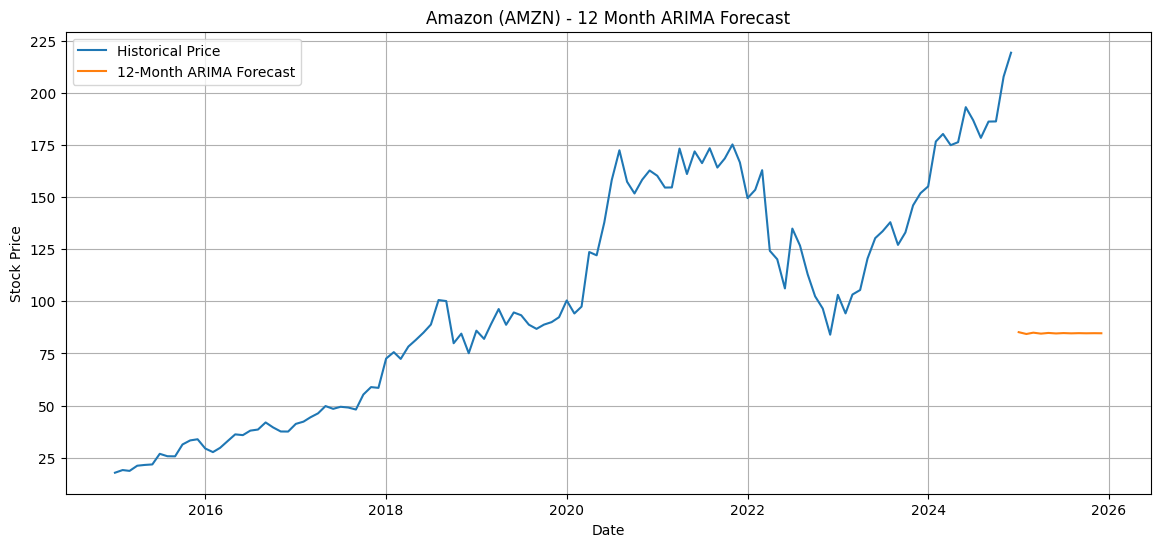


Future 12-Month Forecast:
         Date   Forecast
0  2025-01-01  85.214408
1  2025-02-01  84.334094
2  2025-03-01  84.972226
3  2025-04-01  84.509650
4  2025-05-01  84.844967
5  2025-06-01  84.601899
6  2025-07-01  84.778097
7  2025-08-01  84.650372
8  2025-09-01  84.742959
9  2025-10-01  84.675844
10 2025-11-01  84.724495
11 2025-12-01  84.689228

ARIMA analysis completed successfully!
Forecast saved as: Amazon_ARIMA_Forecast.csv


In [1]:
# ============================================================
# ARIMA MODEL - AMAZON (AMZN) STOCK PRICE
# ============================================================

# Install required library
!pip install yfinance statsmodels -q


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ============================================================
# 2. DOWNLOAD AMAZON STOCK DATA
# ============================================================

amazon = yf.download(
    "AMZN",
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True
)

print("Amazon stock data:")
print(amazon.head())


# ============================================================
# 3. SELECT CLOSING PRICE
# ============================================================

data = amazon["Close"]

# Handle yfinance MultiIndex
if isinstance(data, pd.DataFrame):
    data = data["AMZN"]

data = data.dropna()


# ============================================================
# 4. CONVERT DAILY DATA TO MONTHLY DATA
# ============================================================

monthly_data = data.resample("MS").last()

monthly_data = monthly_data.dropna()

print("\nMonthly data:")
print(monthly_data.head())


# ============================================================
# 5. PLOT ORIGINAL DATA
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_data.index,
    monthly_data.values
)

plt.title("Amazon (AMZN) Monthly Stock Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)

plt.show()


# ============================================================
# 6. CHECK STATIONARITY USING ADF TEST
# ============================================================

adf_test = adfuller(monthly_data)

print("\nADF TEST")
print("--------------------------------")

print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])

if adf_test[1] <= 0.05:
    print("The data is stationary.")
else:
    print("The data is NOT stationary.")
    print("Differencing is required.")


# ============================================================
# 7. DIFFERENCE THE DATA
# ============================================================

diff_data = monthly_data.diff().dropna()


# ============================================================
# 8. CHECK STATIONARITY AFTER DIFFERENCING
# ============================================================

adf_test_diff = adfuller(diff_data)

print("\nADF TEST AFTER DIFFERENCING")
print("--------------------------------")

print("ADF Statistic:", adf_test_diff[0])
print("p-value:", adf_test_diff[1])

if adf_test_diff[1] <= 0.05:
    print("The differenced data is stationary.")
else:
    print("The differenced data is still NOT stationary.")


# ============================================================
# 9. PLOT DIFFERENCED DATA
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    diff_data.index,
    diff_data.values
)

plt.title("Differenced Amazon Stock Price")
plt.xlabel("Date")
plt.ylabel("Difference")

plt.grid(True)
plt.show()


# ============================================================
# 10. TRAIN-TEST SPLIT
# ============================================================

train_size = int(len(monthly_data) * 0.80)

train = monthly_data.iloc[:train_size]
test = monthly_data.iloc[train_size:]

print("\nTraining observations:", len(train))
print("Testing observations:", len(test))


# ============================================================
# 11. BUILD ARIMA MODEL
# ============================================================

# ARIMA(p,d,q)
#
# p = autoregressive order
# d = differencing order
# q = moving average order
#
# Here:
# p = 1
# d = 1
# q = 1

model = ARIMA(
    train,
    order=(1, 1, 1)
)

model_fit = model.fit()


# ============================================================
# 12. MODEL SUMMARY
# ============================================================

print("\nARIMA MODEL SUMMARY")
print("--------------------------------")

print(model_fit.summary())


# ============================================================
# 13. FORECAST TEST PERIOD
# ============================================================

forecast = model_fit.forecast(
    steps=len(test)
)


# ============================================================
# 14. PLOT ACTUAL VS FORECAST
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train.values,
    label="Training Data"
)

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    test.index,
    forecast,
    label="ARIMA Forecast"
)

plt.title(
    "Amazon Stock Price - ARIMA Forecast"
)

plt.xlabel("Date")
plt.ylabel("Stock Price")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 15. CALCULATE ERROR
# ============================================================

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

mae = mean_absolute_error(
    test,
    forecast
)


print("\nMODEL PERFORMANCE")
print("--------------------------------")

print("MAE :", mae)
print("RMSE:", rmse)


# ============================================================
# 16. FORECAST FUTURE 12 MONTHS
# ============================================================

future_forecast = model_fit.forecast(
    steps=12
)


# ============================================================
# 17. CREATE FUTURE DATES
# ============================================================

future_dates = pd.date_range(
    start=monthly_data.index[-1] + pd.offsets.MonthBegin(1),
    periods=12,
    freq="MS"
)


# ============================================================
# 18. PLOT FUTURE FORECAST
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_data.index,
    monthly_data.values,
    label="Historical Price"
)

plt.plot(
    future_dates,
    future_forecast,
    label="12-Month ARIMA Forecast"
)

plt.title(
    "Amazon (AMZN) - 12 Month ARIMA Forecast"
)

plt.xlabel("Date")
plt.ylabel("Stock Price")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 19. DISPLAY FUTURE FORECAST
# ============================================================

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_forecast.values
})

print("\nFuture 12-Month Forecast:")
print(forecast_df)


# ============================================================
# 20. SAVE FORECAST
# ============================================================

forecast_df.to_csv(
    "Amazon_ARIMA_Forecast.csv",
    index=False
)

print("\n========================================")
print("ARIMA analysis completed successfully!")
print("========================================")
print("Forecast saved as: Amazon_ARIMA_Forecast.csv")